# Clustering TEC21 vs Pre-TEC21 — K = 6

Análisis independiente de K-Means para **Pre-TEC21** y **TEC21** con 8 features académico-socioeconómicas.  
Los clusters se ordenan de **C0 (menor deserción) → C5 (mayor deserción)**.

| Feature | Descripción |
|---------|-------------|
| `PNA` | Promedio Normalizado de Admisión |
| `is_foreign` | Extranjero (1) / Nacional (0) |
| `estuvo.prepa_tec` | Egresado de Preparatoria Tec |
| `first.generation.yes` | Primera generación universitaria |
| `has_extracurriculars` | Actividades extracurriculares |
| `parents_exatec_enc` | Padres EXATEC |
| `total.scholarship.loan` | Beca o préstamo |
| `FTE` | Carga académica |

**Variable objetivo:** `retention` (0 = desertor · 1 = retenido)


## 1. Imports y configuración

In [233]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine as cos_dist
from scipy.optimize import linear_sum_assignment

SEED = 42
K    = 6
DATA = '../data/dataset_k_means.csv'
OUT  = '../data/'

PALETTE = ['#16a34a','#22c55e','#3b82f6','#f59e0b','#f97316','#ef4444']

FEATURES = ['PNA','is_foreign','estuvo.prepa_tec','first.generation.yes',
            'has_extracurriculars','parents_exatec_enc','total.scholarship.loan','FTE', 'socioec_enc']

LABELS = {'PNA':'PNA','is_foreign':'Extranjero','estuvo.prepa_tec':'Prepa Tec',
          'first.generation.yes':'Primera gen.','has_extracurriculars':'Extracurricular',
          'parents_exatec_enc':'Padres EXATEC','total.scholarship.loan':'Beca/Préstamo',
          'FTE':'Carga FTE', 'socioec_enc':'Nivel socioeconómico'}
print("✓ Listo  K =", K)


✓ Listo  K = 6


## 2. Carga y feature engineering

In [234]:
df_raw = pd.read_csv(DATA)
df_raw['is_foreign'] = df_raw['foreign_Yes: Foreigner'].astype(int)
df_raw['dropout']    = 1 - df_raw['retention']

pre_df = df_raw[df_raw['educational.model']==0].copy().reset_index(drop=True)
tec_df = df_raw[df_raw['educational.model']==1].copy().reset_index(drop=True)

print(f"Dataset total : n={len(df_raw):,}")
print(f"Pre-TEC21     : n={len(pre_df):,}  dropout={pre_df['dropout'].mean()*100:.2f}%")
print(f"TEC21         : n={len(tec_df):,}  dropout={tec_df['dropout'].mean()*100:.2f}%")
print(f"Extranjeros   : n={df_raw['is_foreign'].sum():,}  ({df_raw['is_foreign'].mean()*100:.1f}%)")
print(f"Primera gen   : n={df_raw['first.generation.yes'].sum():,}")


Dataset total : n=77,517
Pre-TEC21     : n=53,010  dropout=8.84%
TEC21         : n=24,507  dropout=8.68%
Extranjeros   : n=2,638  (3.4%)
Primera gen   : n=5,773


## 3. Preprocesamiento y funciones auxiliares

In [235]:
def preprocess(sub):
    valid = [f for f in FEATURES if f in sub.columns and sub[f].std() > 0]
    X = sub[valid].fillna(sub[valid].median()).values.astype(float)
    return StandardScaler().fit_transform(X), valid

def reorder_clusters(labels, y):
    """C0 = menor deserción … C(K-1) = mayor deserción."""
    order   = np.argsort([y[labels==k].mean() for k in range(K)])
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[l] for l in labels])

def build_profile(sub, labels, feats, y_out):
    df_c  = sub[feats].copy()
    means = df_c.groupby(labels).mean()
    z     = (means - df_c.mean()) / df_c.std()
    z.index.name = 'cluster'
    z['Deserción (%)'] = [y_out[labels==k].mean()*100 for k in range(K)]
    z['n']             = [int((labels==k).sum())       for k in range(K)]
    return z

X_pre, feat_pre = preprocess(pre_df)
X_tec, feat_tec = preprocess(tec_df)
y_pre = pre_df['dropout'].values
y_tec = tec_df['dropout'].values
print(f"Features ({len(feat_pre)}): {feat_pre}")
print(f"X_pre {X_pre.shape}  X_tec {X_tec.shape}")


Features (8): ['PNA', 'is_foreign', 'estuvo.prepa_tec', 'first.generation.yes', 'has_extracurriculars', 'parents_exatec_enc', 'total.scholarship.loan', 'FTE']
X_pre (53010, 8)  X_tec (24507, 8)


## 4. Selección del número de clusters (K)

Calculando métricas Pre-TEC21…
Calculando métricas TEC21…


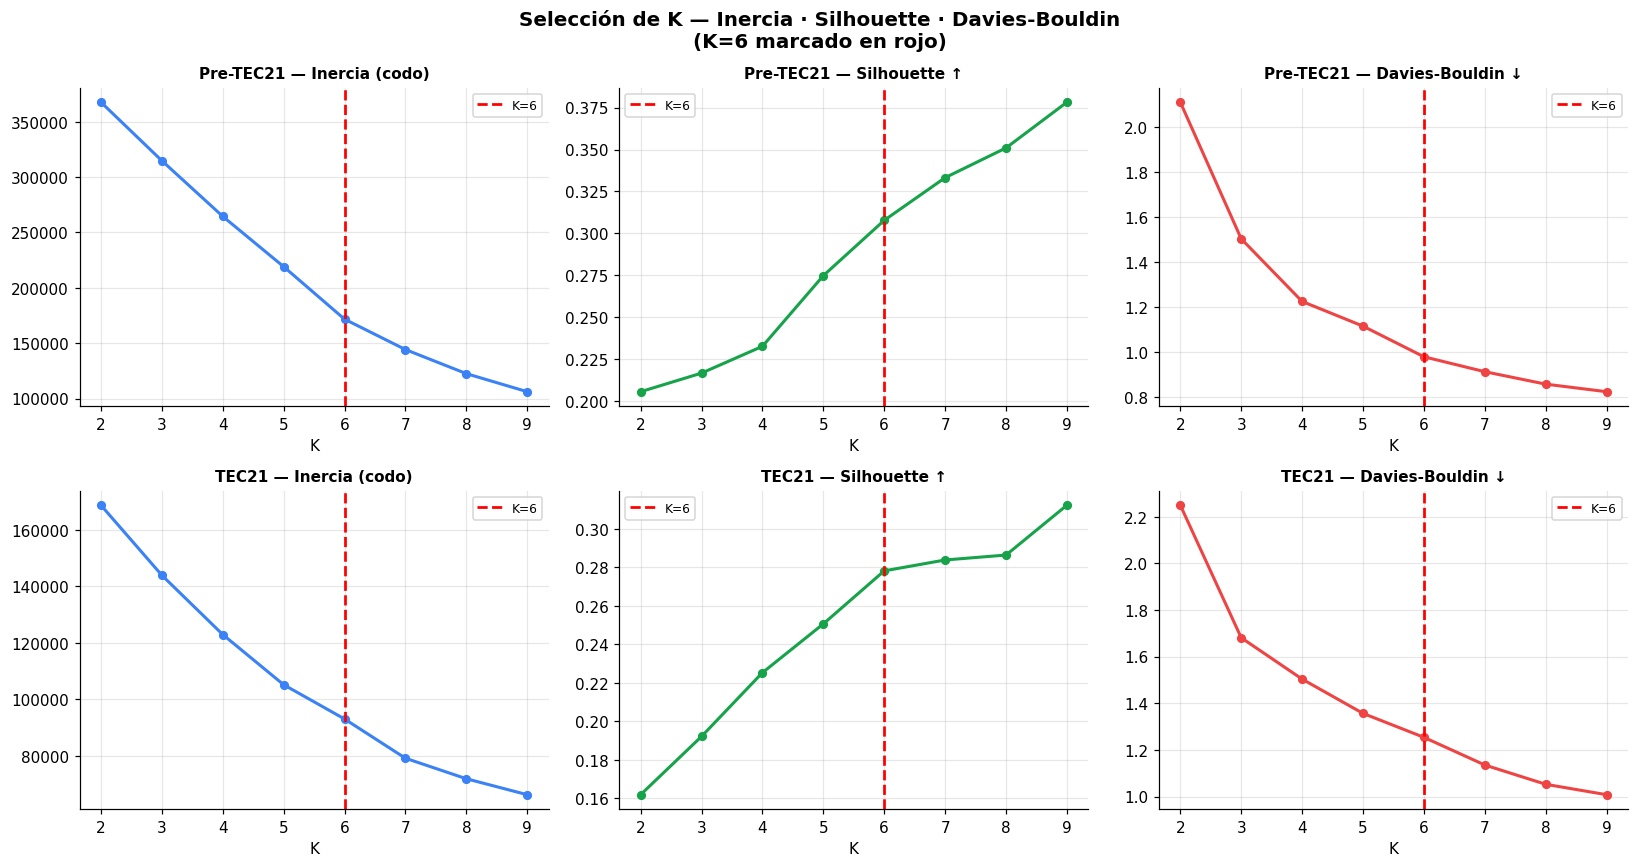

In [236]:
K_RANGE = range(2, 10)

def k_metrics(X, sample=5000):
    idx = np.random.default_rng(SEED).choice(len(X), min(sample, len(X)), replace=False)
    Xs  = X[idx]
    iner, sils, dbs = [], [], []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=15).fit(X)
        iner.append(km.inertia_)
        ls = km.predict(Xs)
        sils.append(silhouette_score(Xs, ls))
        dbs.append(davies_bouldin_score(Xs, ls))
    return iner, sils, dbs

print("Calculando métricas Pre-TEC21…")
i_pre, s_pre, d_pre = k_metrics(X_pre)
print("Calculando métricas TEC21…")
i_tec, s_tec, d_tec = k_metrics(X_tec)

ks = list(K_RANGE)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Selección de K — Inercia · Silhouette · Davies-Bouldin\n(K=6 marcado en rojo)',
             fontweight='bold', fontsize=13)

for row, (iner, sil, db, lbl) in enumerate([
        (i_pre, s_pre, d_pre, 'Pre-TEC21'),
        (i_tec, s_tec, d_tec, 'TEC21')]):
    for ax, vals, title, col in [
            (axes[row,0], iner, 'Inercia (codo)', '#3b82f6'),
            (axes[row,1], sil,  'Silhouette ↑',  '#16a34a'),
            (axes[row,2], db,   'Davies-Bouldin ↓','#ef4444')]:
        ax.plot(ks, vals, 'o-', color=col, lw=2, ms=5)
        ax.axvline(K, color='red', ls='--', lw=1.8, label=f'K={K}')
        ax.set_title(f'{lbl} — {title}', fontsize=10, fontweight='bold')
        ax.set_xlabel('K'); ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.tight_layout()
plt.show()


## 5. K-Means con K = 6 y métricas

In [237]:
km_pre = KMeans(n_clusters=K, random_state=SEED, n_init=20).fit(X_pre)
km_tec = KMeans(n_clusters=K, random_state=SEED, n_init=20).fit(X_tec)
lbl_pre = reorder_clusters(km_pre.labels_, y_pre)
lbl_tec = reorder_clusters(km_tec.labels_, y_tec)

sil_pre = silhouette_score(X_pre, lbl_pre)
sil_tec = silhouette_score(X_tec, lbl_tec)
db_pre  = davies_bouldin_score(X_pre, lbl_pre)
db_tec  = davies_bouldin_score(X_tec, lbl_tec)

print("Métricas K=6")
print(f"  Pre-TEC21 → Silhouette={sil_pre:.3f}  Davies-Bouldin={db_pre:.3f}")
print(f"  TEC21     → Silhouette={sil_tec:.3f}  Davies-Bouldin={db_tec:.3f}")
print()

header = f"{'Cluster':8} {'n':>7} {'%grupo':>7} {'Dropout%':>9} {'PNA':>6} {'Foreign':>8} {'PrepaTec':>9} {'1ºGen':>7} {'Extra':>7} {'Beca':>7}"
print(header); print('-'*len(header))
for k in range(K):
    m = lbl_pre==k
    row = [pre_df[f].values[m].mean() for f in FEATURES]
    print(f"  Pre-C{k}  {m.sum():>7,} {m.sum()/len(pre_df)*100:>6.1f}% {y_pre[m].mean()*100:>8.1f}% "
          f"{row[0]:>6.1f} {row[1]:>8.2f} {row[2]:>9.2f} {row[3]:>7.2f} {row[4]:>7.2f} {row[6]:>7.2f}")
print()
print(header); print('-'*len(header))
for k in range(K):
    m = lbl_tec==k
    row = [tec_df[f].values[m].mean() for f in FEATURES]
    print(f"  TEC-C{k}  {m.sum():>7,} {m.sum()/len(tec_df)*100:>6.1f}% {y_tec[m].mean()*100:>8.1f}% "
          f"{row[0]:>6.1f} {row[1]:>8.2f} {row[2]:>9.2f} {row[3]:>7.2f} {row[4]:>7.2f} {row[6]:>7.2f}")


Métricas K=6
  Pre-TEC21 → Silhouette=0.302  Davies-Bouldin=0.983
  TEC21     → Silhouette=0.265  Davies-Bouldin=1.253

Cluster        n  %grupo  Dropout%    PNA  Foreign  PrepaTec   1ºGen   Extra    Beca
------------------------------------------------------------------------------------
  Pre-C0    5,695   10.7%      4.8%   87.8     0.00      0.60    0.00    1.00    0.24
  Pre-C1   18,221   34.4%      6.1%   91.7     0.00      0.46    0.00    1.00    0.50
  Pre-C2    2,521    4.8%     10.6%   87.9     0.00      0.38    1.00    1.00    0.23
  Pre-C3   24,505   46.2%     11.1%   83.9     0.00      0.51    0.00    1.00    0.05
  Pre-C4    1,667    3.1%     14.2%   88.0     1.00      0.00    0.04    1.00    0.13
  Pre-C5      401    0.8%     20.2%   86.8     0.07      0.44    0.12    0.00    0.14

Cluster        n  %grupo  Dropout%    PNA  Foreign  PrepaTec   1ºGen   Extra    Beca
------------------------------------------------------------------------------------
  TEC-C0    7,510   30.

## 6. Resumen de métricas por cluster

In [238]:
rows = []
for grp, sub, labels, y_out in [
        ('Pre-TEC21', pre_df, lbl_pre, y_pre),
        ('TEC21',     tec_df, lbl_tec, y_tec)]:
    for k in range(K):
        m = labels==k
        rows.append({
            'Grupo': grp, 'Cluster': f'C{k}',
            'n': int(m.sum()),
            '% grupo': round(m.sum()/len(sub)*100, 1),
            'Dropout %': round(y_out[m].mean()*100, 2),
            'PNA media': round(sub['PNA'].values[m].mean(), 1),
            '% Extranjero': round(sub['is_foreign'].values[m].mean()*100, 1),
            '% Prepa Tec':  round(sub['estuvo.prepa_tec'].values[m].mean()*100, 1),
            '% Primera gen': round(sub['first.generation.yes'].values[m].mean()*100, 1),
            '% Con beca':   round(sub['total.scholarship.loan'].values[m].mean()*100, 1),
            '% Extracurr.': round(sub['has_extracurriculars'].values[m].mean()*100, 1),
        })

df_metrics = pd.DataFrame(rows)
print("=== MÉTRICAS GLOBALES ===")
global_m = pd.DataFrame({
    'Grupo': ['Pre-TEC21','TEC21'],
    'n': [len(pre_df), len(tec_df)],
    'Dropout global %': [round(y_pre.mean()*100,2), round(y_tec.mean()*100,2)],
    'Silhouette K=6': [round(sil_pre,3), round(sil_tec,3)],
    'Davies-Bouldin': [round(db_pre,3), round(db_tec,3)],
})
print(global_m.to_string(index=False))
print()
print("=== POR CLUSTER ===")
print(df_metrics.to_string(index=False))
df_metrics.to_csv(OUT+'v5_metricas_clusters.csv', index=False)
print("\n✓ v5_metricas_clusters.csv")


=== MÉTRICAS GLOBALES ===
    Grupo     n  Dropout global %  Silhouette K=6  Davies-Bouldin
Pre-TEC21 53010              8.84           0.302           0.983
    TEC21 24507              8.68           0.265           1.253

=== POR CLUSTER ===
    Grupo Cluster     n  % grupo  Dropout %  PNA media  % Extranjero  % Prepa Tec  % Primera gen  % Con beca  % Extracurr.
Pre-TEC21      C0  5695     10.7       4.79       87.8           0.0         59.9            0.0        24.1         100.0
Pre-TEC21      C1 18221     34.4       6.13       91.7           0.0         46.3            0.0        50.4         100.0
Pre-TEC21      C2  2521      4.8      10.55       87.9           0.0         37.6          100.0        22.7         100.0
Pre-TEC21      C3 24505     46.2      11.06       83.9           0.0         50.9            0.0         4.6         100.0
Pre-TEC21      C4  1667      3.1      14.22       88.0         100.0          0.4            4.4        13.0         100.0
Pre-TEC21      C5

## 7. Heatmap de perfiles (z-scores)

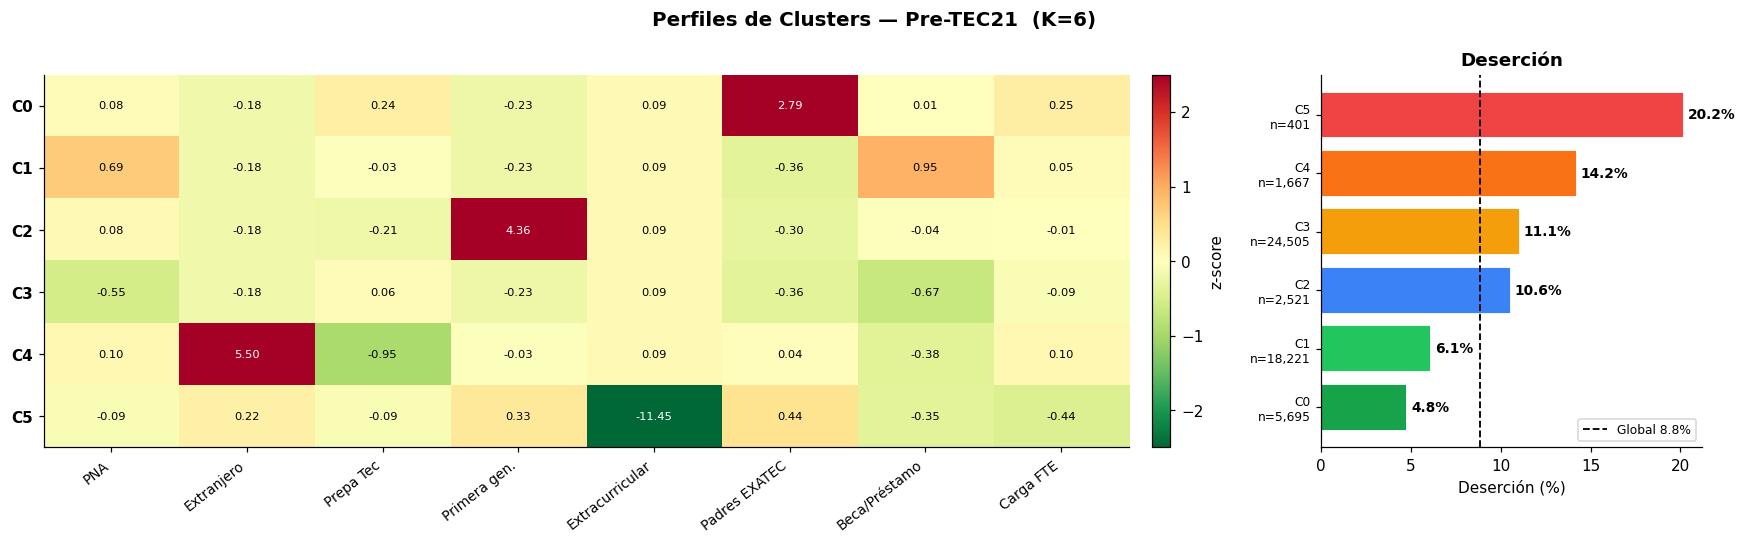

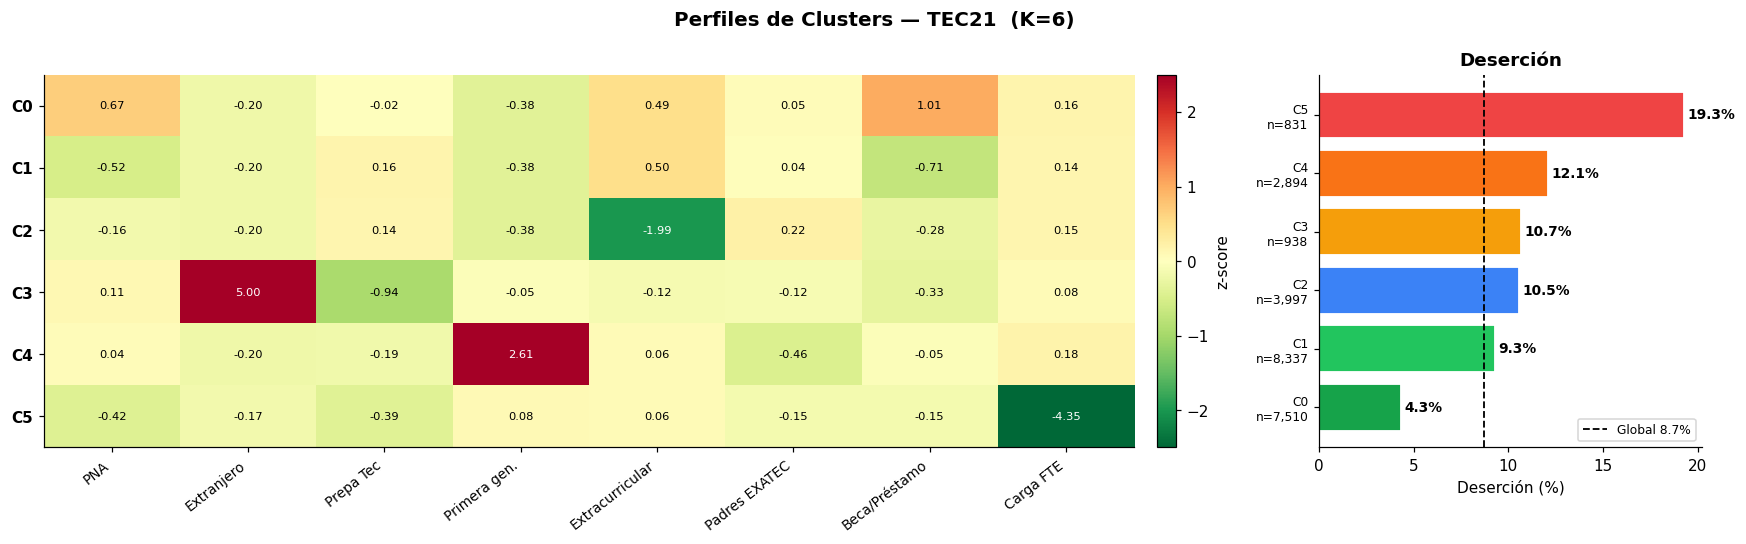

In [239]:
prof_pre = build_profile(pre_df, lbl_pre, feat_pre, y_pre)
prof_tec = build_profile(tec_df, lbl_tec, feat_tec, y_tec)

feat_cols = [c for c in prof_pre.columns if c not in ('Deserción (%)','n')]
pretty    = [LABELS.get(f, f) for f in feat_cols]

for prof, grp_name in [(prof_pre,'Pre-TEC21'), (prof_tec,'TEC21')]:
    fig, (ax_h, ax_b) = plt.subplots(1, 2, figsize=(16, 5),
                                      gridspec_kw={'width_ratios': [3, 1]})
    fig.suptitle(f'Perfiles de Clusters — {grp_name}  (K={K})',
                 fontsize=13, fontweight='bold')

    fc   = [c for c in prof.columns if c not in ('Deserción (%)','n')]
    pr   = [LABELS.get(f,f) for f in fc]
    data = prof[fc].values.astype(float)

    im = ax_h.imshow(data, cmap='RdYlGn_r', aspect='auto', vmin=-2.5, vmax=2.5)
    ax_h.set_xticks(range(len(fc)), labels=pr, rotation=38, ha='right', fontsize=9)
    ax_h.set_yticks(range(K), labels=[f'C{k}' for k in range(K)],
                    fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax_h, label='z-score', fraction=0.03, pad=0.02)
    for i in range(K):
        for j in range(len(fc)):
            v = data[i,j]
            ax_h.text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=7.5, color='white' if abs(v)>1.4 else 'black')

    dvals = prof['Deserción (%)'].values
    ns    = prof['n'].values
    y_gl  = y_pre.mean() if grp_name=='Pre-TEC21' else y_tec.mean()
    bars  = ax_b.barh(range(K), dvals, color=PALETTE[:K], edgecolor='white', lw=1.2)
    ax_b.axvline(y_gl*100, color='black', ls='--', lw=1.2, label=f'Global {y_gl*100:.1f}%')
    ax_b.set_yticks(range(K), labels=[f'C{k}\nn={ns[k]:,}' for k in range(K)], fontsize=8)
    ax_b.set_xlabel('Deserción (%)'); ax_b.set_title('Deserción', fontweight='bold')
    ax_b.legend(fontsize=8)
    for bar, val in zip(bars, dvals):
        ax_b.text(val+0.2, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()


## 8. Silhouette Plot

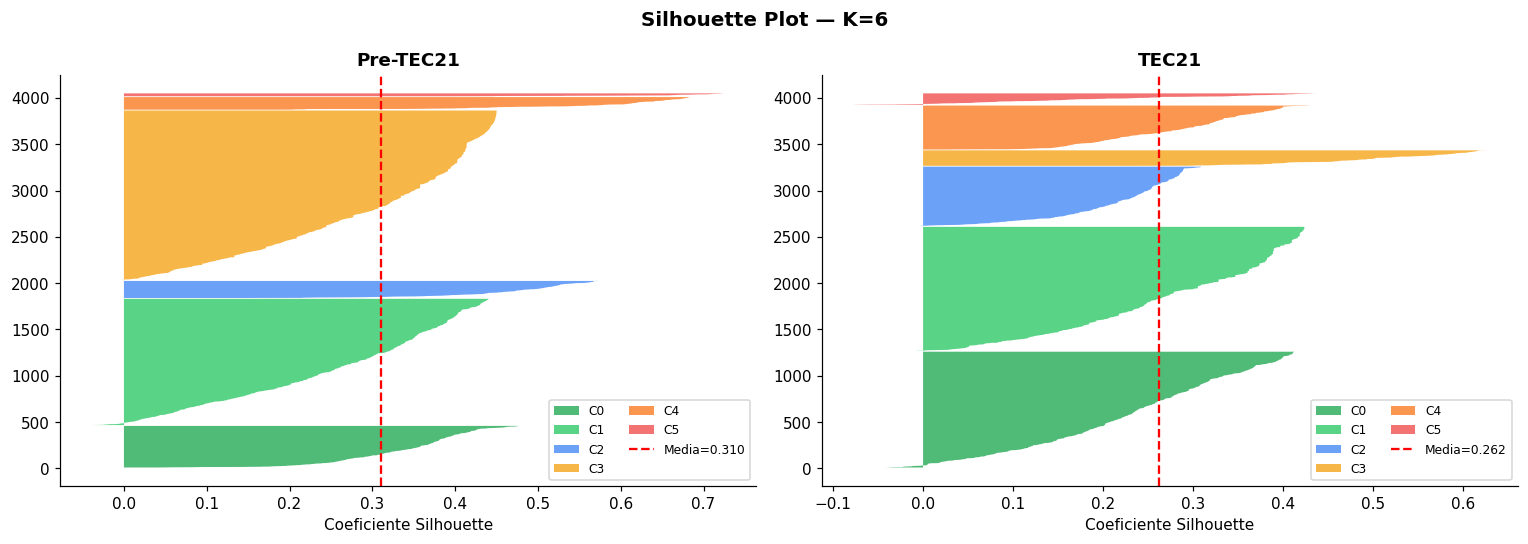

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Silhouette Plot — K=6', fontsize=13, fontweight='bold')

for ax, X, lbl, title in [
        (axes[0], X_pre, lbl_pre, 'Pre-TEC21'),
        (axes[1], X_tec, lbl_tec, 'TEC21')]:
    idx = np.random.default_rng(SEED).choice(len(X), min(4000,len(X)), replace=False)
    sv  = silhouette_samples(X[idx], lbl[idx])
    yl  = 10
    for k in range(K):
        ks  = np.sort(sv[lbl[idx]==k])
        yu  = yl + len(ks)
        ax.fill_betweenx(np.arange(yl, yu), 0, ks,
                         facecolor=PALETTE[k], alpha=.75, label=f'C{k}')
        yl  = yu + 8
    ax.axvline(sv.mean(), color='red', ls='--', lw=1.5, label=f'Media={sv.mean():.3f}')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Coeficiente Silhouette')
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout(); plt.show()


## 9. Proyección PCA 2D

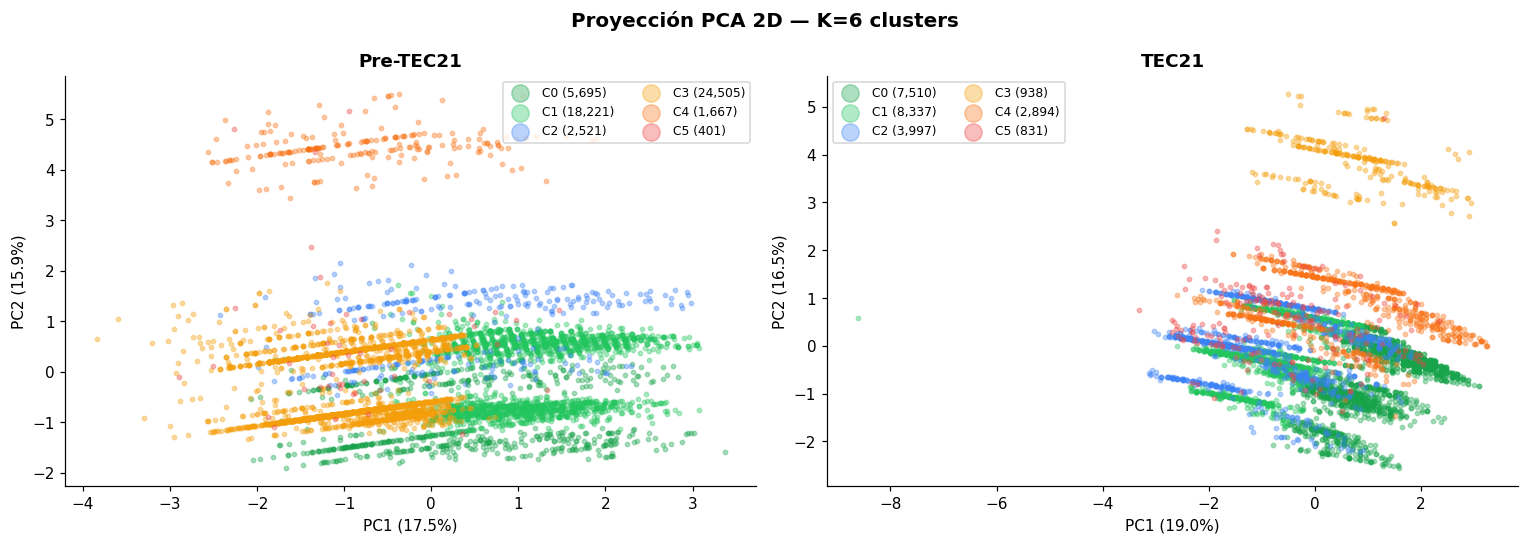

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Proyección PCA 2D — K=6 clusters', fontsize=13, fontweight='bold')

for ax, X, lbl, title in [
        (axes[0], X_pre, lbl_pre, 'Pre-TEC21'),
        (axes[1], X_tec, lbl_tec, 'TEC21')]:
    idx = np.random.default_rng(SEED).choice(len(X), min(6000,len(X)), replace=False)
    pca = PCA(n_components=2, random_state=SEED)
    Xp  = pca.fit_transform(X[idx])
    for k in range(K):
        m = lbl[idx]==k
        ax.scatter(Xp[m,0], Xp[m,1], c=PALETTE[k], alpha=.35, s=8,
                   label=f'C{k} ({(lbl==k).sum():,})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(markerscale=4, fontsize=8, ncol=2)

plt.tight_layout(); plt.show()


## 10. Valores reales por cluster

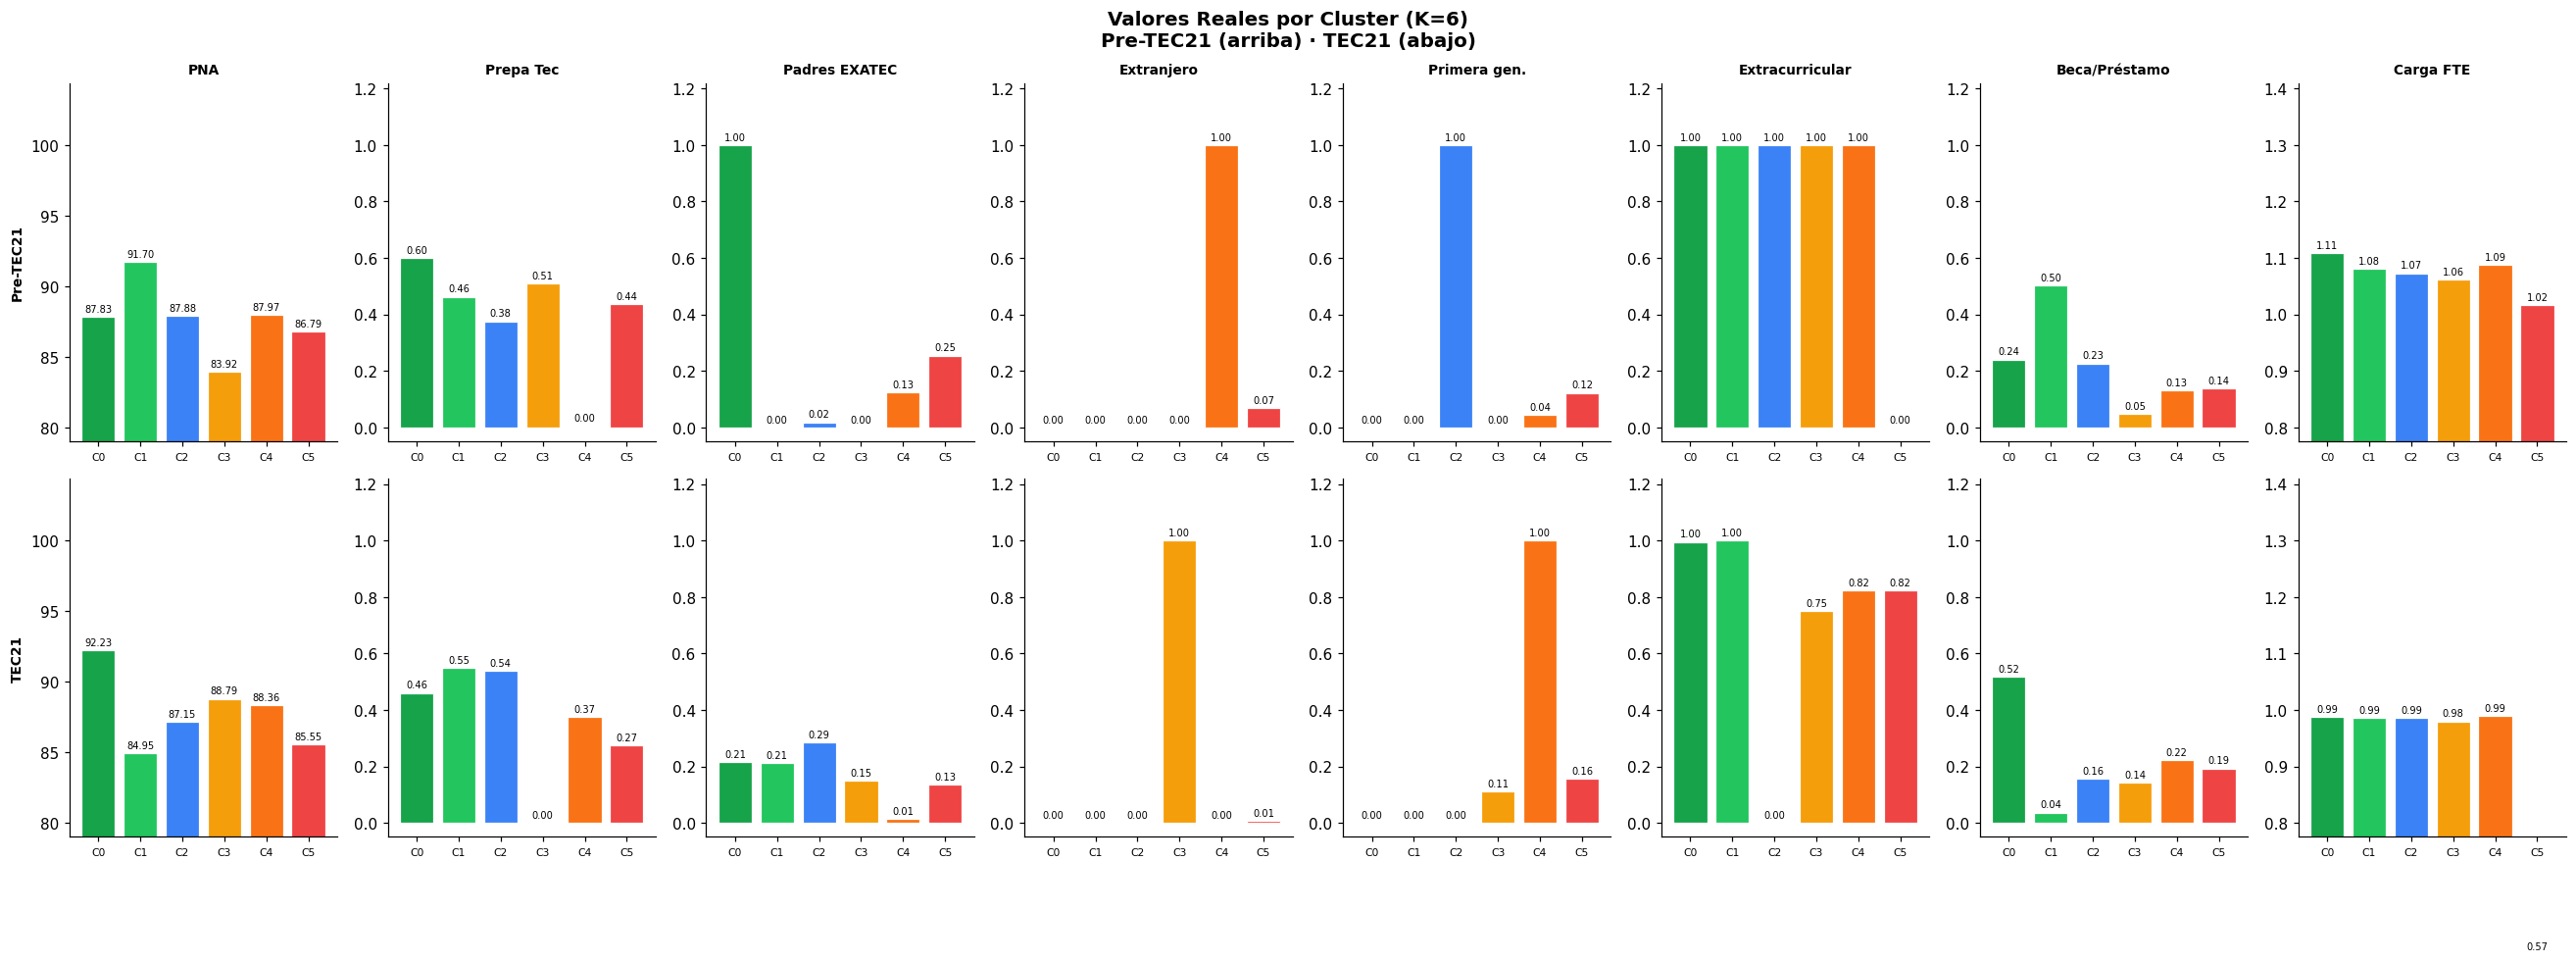

In [242]:
disc = [
    ('PNA',                   'PNA',            80, 100),
    ('estuvo.prepa_tec',      'Prepa Tec',       0,   1),
    ('parents_exatec_enc',    'Padres EXATEC',   0,   1),
    ('is_foreign',            'Extranjero',      0,   1),
    ('first.generation.yes',  'Primera gen.',    0,   1),
    ('has_extracurriculars',  'Extracurricular', 0,   1),
    ('total.scholarship.loan','Beca/Préstamo',   0,   1),
    ('FTE',                   'Carga FTE',     0.8, 1.3),
]

fig, axes = plt.subplots(2, len(disc), figsize=(24, 9))
fig.suptitle('Valores Reales por Cluster (K=6)\nPre-TEC21 (arriba) · TEC21 (abajo)',
             fontsize=13, fontweight='bold')

x = np.arange(K)
for ci, (feat, label, ymin, ymax) in enumerate(disc):
    for ri, (sub, labels, gname) in enumerate([
            (pre_df, lbl_pre, 'Pre-TEC21'),
            (tec_df, lbl_tec, 'TEC21')]):
        ax   = axes[ri, ci]
        vals = [sub[feat].values[labels==k].mean() for k in range(K)]
        rng  = ymax - ymin
        ax.bar(x, vals, color=PALETTE[:K], edgecolor='white', lw=.8)
        ax.set_ylim(ymin - .05*rng, ymax + .22*rng)
        ax.set_xticks(x, labels=[f'C{k}' for k in range(K)], fontsize=7)
        if ci == 0:  ax.set_ylabel(gname, fontsize=9, fontweight='bold')
        if ri == 0:  ax.set_title(label, fontsize=9, fontweight='bold')
        for xi, val in enumerate(vals):
            ax.text(xi, val + .01*rng, f'{val:.2f}', ha='center',
                   va='bottom', fontsize=6.5)

plt.tight_layout(); plt.show()


## 11. Variables más discriminantes por cluster

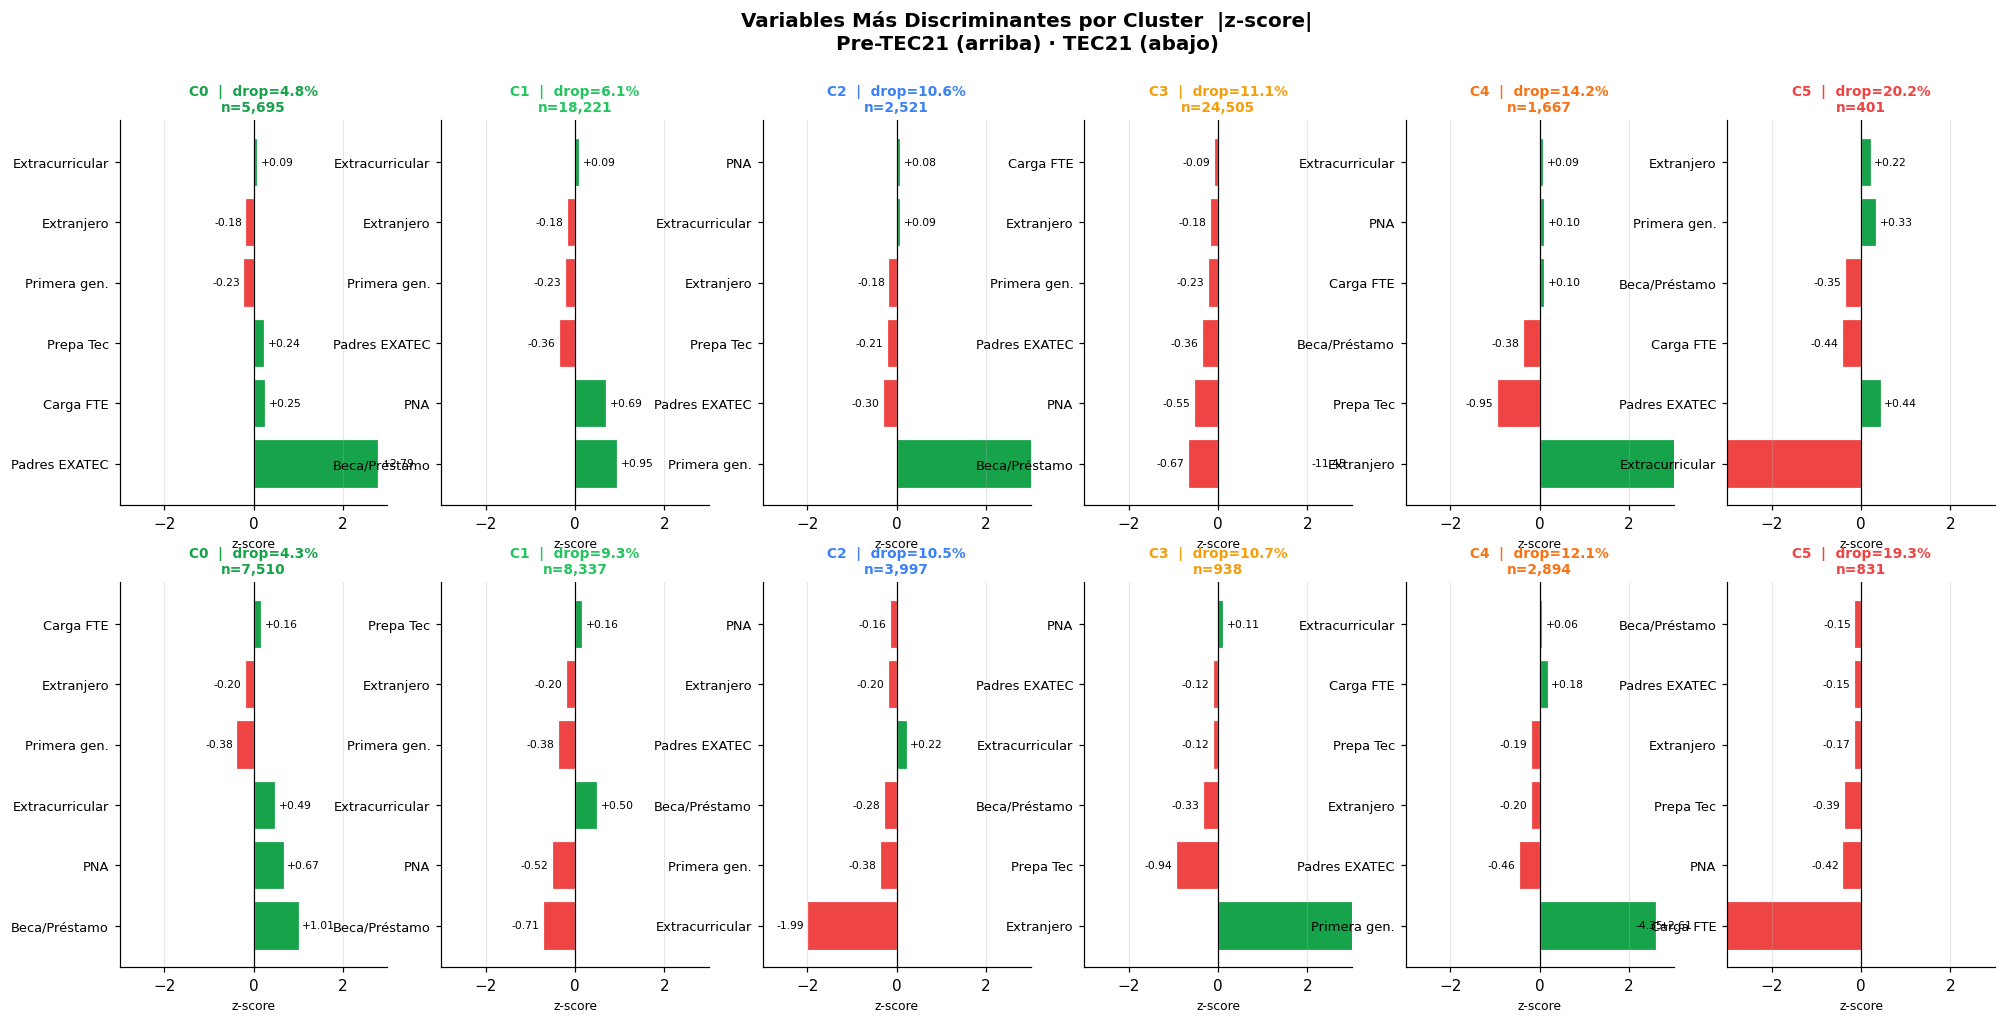

In [243]:
fig, axes = plt.subplots(2, K, figsize=(22, 10))
fig.suptitle('Variables Más Discriminantes por Cluster  |z-score|\nPre-TEC21 (arriba) · TEC21 (abajo)',
             fontsize=13, fontweight='bold')

for ri, (prof, grp_name) in enumerate([(prof_pre,'Pre-TEC21'),(prof_tec,'TEC21')]):
    fc = [c for c in prof.columns if c not in ('Deserción (%)','n')]
    for k in range(K):
        ax     = axes[ri, k]
        z_vals = prof.loc[k, fc].astype(float)
        top    = z_vals.abs().nlargest(6).index
        vals   = z_vals[top].values
        labs   = [LABELS.get(f,f) for f in top]
        cols   = ['#16a34a' if v>0 else '#ef4444' for v in vals]
        drop_k = prof.loc[k,'Deserción (%)']
        n_k    = int(prof.loc[k,'n'])

        ax.barh(range(len(top)), vals, color=cols, edgecolor='white', lw=.8)
        ax.set_yticks(range(len(top)), labels=labs, fontsize=8.5)
        ax.axvline(0, color='black', lw=.8)
        ax.set_xlim(-3, 3); ax.set_xlabel('z-score', fontsize=8)
        ax.set_title(f'C{k}  |  drop={drop_k:.1f}%\nn={n_k:,}',
                     fontsize=9, fontweight='bold', color=PALETTE[k])
        ax.grid(axis='x', alpha=.3)
        for bar, val in zip(ax.patches, vals):
            ax.text(val + (.08 if val>=0 else -.08),
                   bar.get_y()+bar.get_height()/2,
                   f'{val:+.2f}', va='center',
                   ha='left' if val>=0 else 'right', fontsize=7)

plt.tight_layout(); plt.show()


## 12. Radar chart — perfiles superpuestos

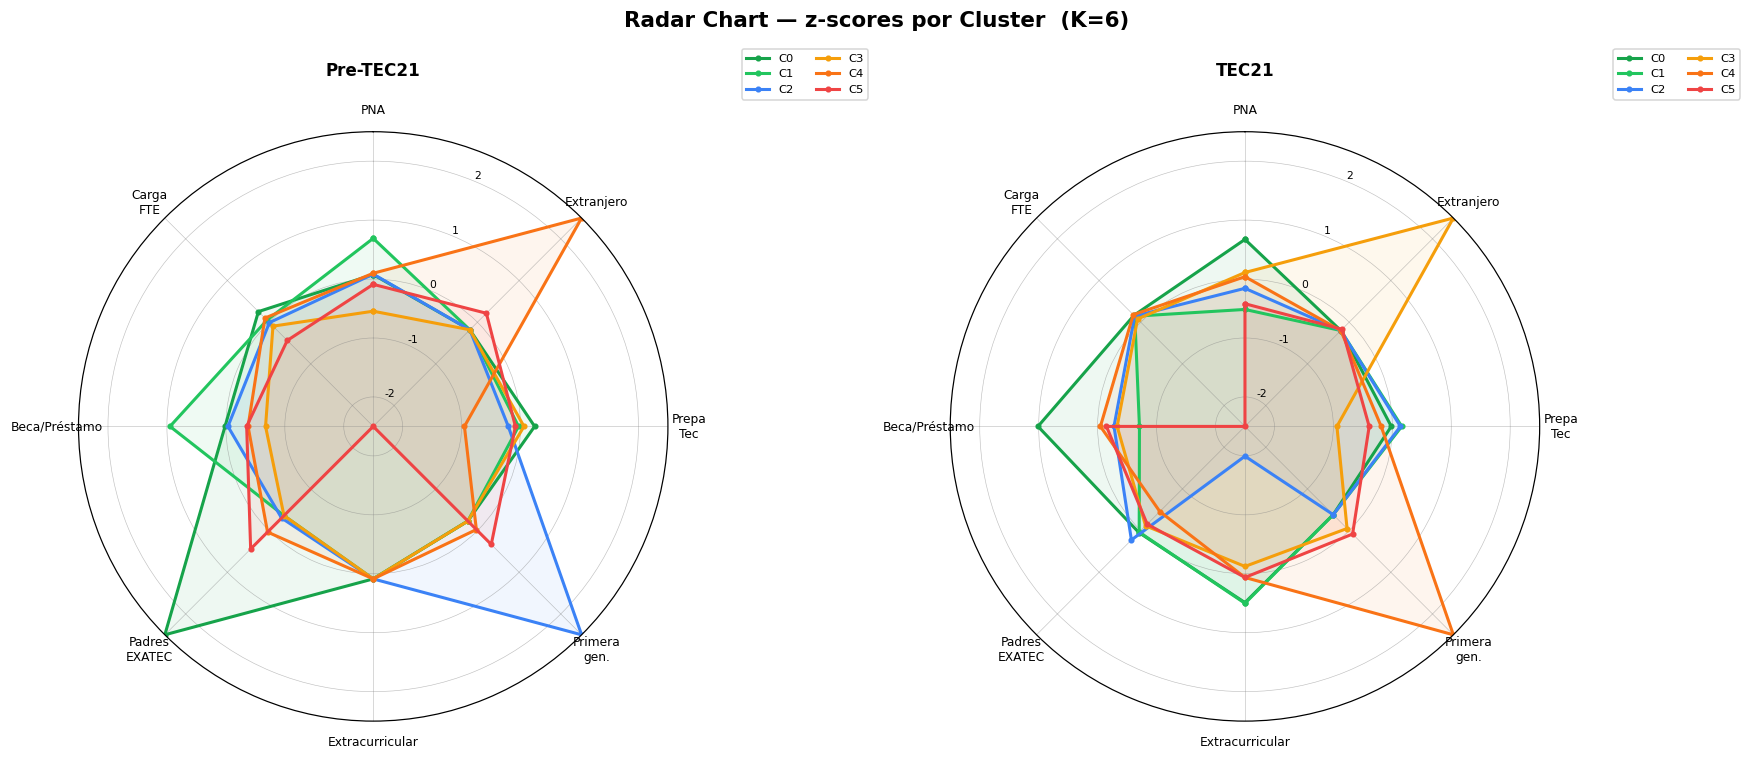

In [244]:
def radar(ax, data, feat_labels, title, palette, k):
    N      = len(feat_labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([l.replace(' ','\n') for l in feat_labels], size=8)
    ax.set_rlim(-2.5, 2.5)
    ax.set_rticks([-2,-1,0,1,2])
    ax.set_yticklabels(['-2','-1','0','1','2'], size=7)
    ax.grid(color='grey', lw=.4, alpha=.5)
    ax.set_title(title, size=11, fontweight='bold', pad=18)
    for i in range(k):
        vals = list(data[i]) + [data[i][0]]
        ax.plot(angles, vals, 'o-', lw=2, color=palette[i], label=f'C{i}', ms=3)
        ax.fill(angles, vals, alpha=.07, color=palette[i])
    ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.15), fontsize=7.5, ncol=2)

fc_r  = [c for c in prof_pre.columns if c not in ('Deserción (%)','n')]
pr_r  = [LABELS.get(f,f) for f in fc_r]
d_pre = np.clip(prof_pre[fc_r].values.astype(float), -2.5, 2.5)
d_tec = np.clip(prof_tec[fc_r].values.astype(float), -2.5, 2.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                subplot_kw=dict(projection='polar'))
fig.suptitle('Radar Chart — z-scores por Cluster  (K=6)', fontsize=14, fontweight='bold')
radar(ax1, d_pre, pr_r, 'Pre-TEC21', PALETTE, K)
radar(ax2, d_tec, pr_r, 'TEC21',     PALETTE, K)
plt.tight_layout(); plt.show()


## 13. Interpretación de los 6 clusters

### Escala de riesgo
🟢 C0 · 🟢 C1 · 🔵 C2 · 🔵 C3 · 🟠 C4 · 🔴 C5

---

## Pre-TEC21

### 🟢 C0 — "Prepa Tec sin beca" · n≈5,695 (10.7%) · Deserción 4.8 %
PNA medio-alto (87.8), Prepa Tec (60 %), sin beca (24 %), sin primera generación.
Extracurriculares al 100 %. El acceso a Prepa Tec los protege aunque no tengan beca.

### 🟢 C1 — "Alto PNA + beca activa" · n≈18,221 (34.4%) · Deserción 6.1 %
El mejor perfil académico de Pre-TEC21 (PNA 91.7). Beca o préstamo en el 50 % de los casos.
Sin primera generación, sin extranjeros. **Menor riesgo entre los grupos grandes.**

### 🔵 C2 — "Primera generación con extracurricular" · n≈2,521 (4.8%) · Deserción 10.6 %
100 % primera generación universitaria, activos en extracurriculares (100 %), beca baja (23 %).
PNA medio (87.9). La participación extracurricular modera el riesgo pero no lo elimina.

### 🔵 C3 — "PNA bajo sin beca" · n≈24,505 (46.2%) · Deserción 11.1 %
El cluster **mayoritario**. PNA más bajo (83.9), casi sin beca (5 %), sin primera generación.
Al no tener apoyo financiero y con menor preparación de admisión, casi duplica el riesgo de C1.
**Mayor impacto potencial de intervención por tamaño del grupo.**

### 🟠 C4 — "Extranjeros" · n≈1,667 (3.1%) · Deserción 14.2 %
100 % extranjeros, sin Prepa Tec (0 %), beca mínima (13 %).
Las barreras culturales, económicas y de adaptación elevan el riesgo.
**Variable más discriminante:** `is_foreign` (z ≫ 0).

### 🔴 C5 — "Sin extracurriculares" · n≈401 (0.8%) · Deserción 20.2 %
Único cluster con **0 % de extracurriculares**. Grupo pequeño pero con la deserción más alta.
PNA medio (86.8), algunos padres EXATEC (25 %), primera generación (12 %).
La ausencia de involucramiento social o institucional es el factor de riesgo dominante.

---

## TEC21

### 🟢 C0 — "Alto PNA + beca activa" · n≈7,510 (30.6%) · Deserción 4.3 %
PNA más alto de TEC21 (92.2), beca alta (52 %), 100 % extracurriculares, sin primera generación.
Equivalente directo de Pre-C1. **Dropout más bajo de todo el análisis.**

### 🟢 C1 — "PNA bajo sin beca" · n≈8,337 (34.0%) · Deserción 9.3 %
PNA bajo (85.0), casi sin beca (4 %), 100 % extracurriculares, mayoría con Prepa Tec (55 %).
Equivalente directo de Pre-C3, aunque la deserción es algo menor en TEC21.

### 🔵 C2 — "Sin extracurriculares TEC21" · n≈3,997 (16.3%) · Deserción 10.5 %
PNA medio (87.1), Prepa Tec (54 %), **0 % extracurriculares**, beca moderada (16 %).
Perfil sin equivalente claro en Pre-TEC21 como cluster separado — en TEC21 este grupo es más grande (16.3 %).

### 🔵 C3 — "Extranjeros TEC21" · n≈938 (3.8%) · Deserción 10.7 %
100 % extranjeros, sin Prepa Tec. Equivalente exacto de Pre-C4 (sim=0.999).
Deserción menor que en Pre-TEC21 (10.7 % vs 14.2 %): posible mejor soporte institucional.

### 🟠 C4 — "Primera generación TEC21" · n≈2,894 (11.8%) · Deserción 12.1 %
100 % primera generación, casi sin padres EXATEC (1.4 %), beca (22 %).
Equivalente de Pre-C2. El modelo TEC21 parece aumentar el riesgo relativo de este grupo (+1.5 pp).

### 🔴 C5 — "Perfil vulnerable TEC21" · n≈831 (3.4%) · Deserción 19.3 %
PNA bajo (85.5), poca Prepa Tec (27 %), primera generación (16 %), casi sin padres EXATEC.
Deserción casi igual que Pre-C5 (19.3 % vs 20.2 %). **Segundo grupo de mayor riesgo del sistema.**


## 14. Matching Pre-TEC21 ↔ TEC21 (algoritmo húngaro)

In [245]:
X_pre_sh = StandardScaler().fit_transform(pre_df[feat_pre].values.astype(float))
X_tec_sh = StandardScaler().fit_transform(tec_df[feat_tec].values.astype(float))

c_pre = np.array([X_pre_sh[lbl_pre==k].mean(0) for k in range(K)])
c_tec = np.array([X_tec_sh[lbl_tec==k].mean(0) for k in range(K)])

sim_matrix = np.array([[max(0., 1-cos_dist(c_pre[i], c_tec[j]))
                        for j in range(K)] for i in range(K)])

ri, ci_match = linear_sum_assignment(-sim_matrix)
match_pairs = [(r, c, sim_matrix[r,c]) for r,c in zip(ri, ci_match)]

sim_df = pd.DataFrame(sim_matrix,
    index=[f'Pre-C{k}' for k in range(K)],
    columns=[f'TEC-C{k}' for k in range(K)])
print("Matriz de similitud coseno:")
print(sim_df.round(3).to_string())
print()
print("Matching óptimo (algoritmo húngaro):")
for r, c, s in match_pairs:
    dr = y_pre[lbl_pre==r].mean()*100
    dc = y_tec[lbl_tec==c].mean()*100
    tag = '🟢 Sólido' if s>=.6 else ('🟡 Moderado' if s>=.2 else '🔴 Débil')
    print(f"  {tag}  Pre-C{r} ({dr:.1f}%) ↔ TEC-C{c} ({dc:.1f}%)  sim={s:.3f}")


Matriz de similitud coseno:
        TEC-C0  TEC-C1  TEC-C2  TEC-C3  TEC-C4  TEC-C5
Pre-C0   0.102   0.094   0.107   0.000   0.000   0.000
Pre-C1   0.900   0.000   0.000   0.000   0.000   0.000
Pre-C2   0.000   0.000   0.000   0.000   0.991   0.028
Pre-C3   0.000   0.817   0.066   0.000   0.000   0.181
Pre-C4   0.000   0.000   0.000   0.999   0.000   0.000
Pre-C5   0.000   0.000   0.952   0.044   0.000   0.024

Matching óptimo (algoritmo húngaro):
  🔴 Débil  Pre-C0 (4.8%) ↔ TEC-C5 (19.3%)  sim=0.000
  🟢 Sólido  Pre-C1 (6.1%) ↔ TEC-C0 (4.3%)  sim=0.900
  🟢 Sólido  Pre-C2 (10.6%) ↔ TEC-C4 (12.1%)  sim=0.991
  🟢 Sólido  Pre-C3 (11.1%) ↔ TEC-C1 (9.3%)  sim=0.817
  🟢 Sólido  Pre-C4 (14.2%) ↔ TEC-C3 (10.7%)  sim=0.999
  🟢 Sólido  Pre-C5 (20.2%) ↔ TEC-C2 (10.5%)  sim=0.952


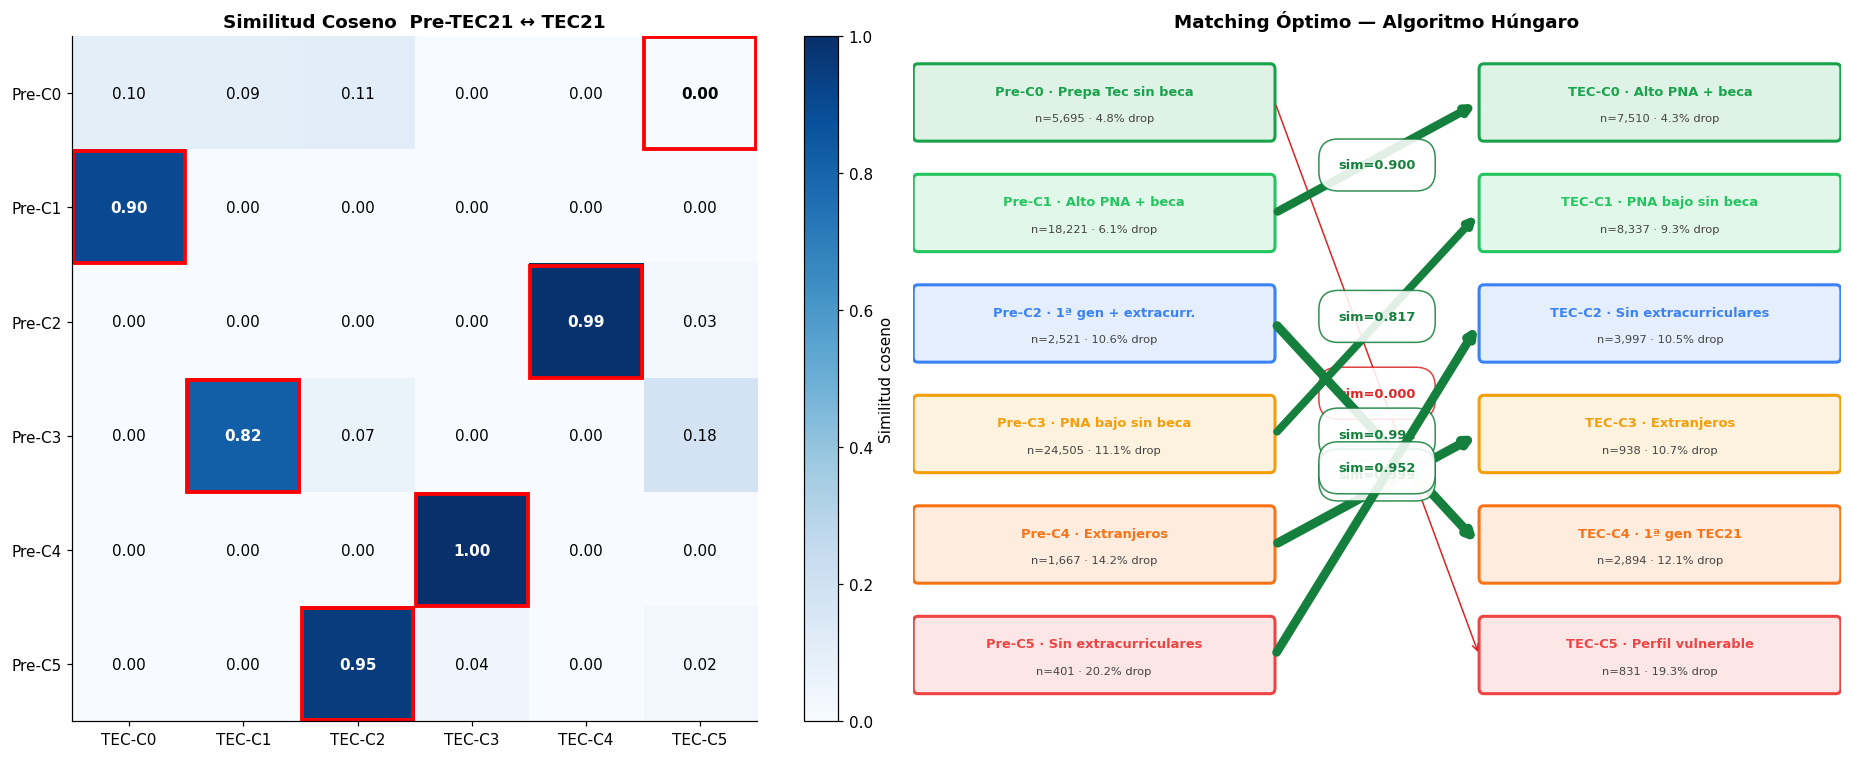

In [246]:
# ── Visualización matching ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap de similitud
ax_h = axes[0]
im = ax_h.imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1)
ax_h.set_xticks(range(K), labels=[f'TEC-C{k}' for k in range(K)], fontsize=10)
ax_h.set_yticks(range(K), labels=[f'Pre-C{k}' for k in range(K)], fontsize=10)
ax_h.set_title('Similitud Coseno  Pre-TEC21 ↔ TEC21', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax_h, label='Similitud coseno', fraction=0.04)
for i in range(K):
    for j in range(K):
        matched = any(r==i and c==j for r,c,_ in match_pairs)
        ax_h.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                 fontsize=10, fontweight='bold' if matched else 'normal',
                 color='white' if sim_matrix[i,j]>.6 else 'black')
        if matched:
            ax_h.add_patch(plt.Rectangle((j-.49,i-.49),.98,.98,
                           fill=False, edgecolor='red', lw=2.5))

# Diagrama de flechas
ax_f = axes[1]
ax_f.set_xlim(0,10); ax_f.set_ylim(-.6, K-.4); ax_f.axis('off')
ax_f.set_title('Matching Óptimo — Algoritmo Húngaro', fontweight='bold', fontsize=12)
yp = list(range(K-1,-1,-1))

NAMES_PRE = ['Prepa Tec sin beca','Alto PNA + beca','1ª gen + extracurr.',
             'PNA bajo sin beca','Extranjeros','Sin extracurriculares']
NAMES_TEC = ['Alto PNA + beca','PNA bajo sin beca','Sin extracurriculares',
             'Extranjeros','1ª gen TEC21','Perfil vulnerable']

for k in range(K):
    col = PALETTE[k]
    n_p = int((lbl_pre==k).sum()); dr_p = y_pre[lbl_pre==k].mean()*100
    ax_f.add_patch(mpatches.FancyBboxPatch((.05,yp[k]-.3),3.8,.6,
        boxstyle='round,pad=0.05', facecolor=col+'22', edgecolor=col, lw=2))
    ax_f.text(1.95,yp[k]+.07,f'Pre-C{k} · {NAMES_PRE[k]}',
             fontsize=8.5, fontweight='bold', color=col, ha='center')
    ax_f.text(1.95,yp[k]-.17,f'n={n_p:,} · {dr_p:.1f}% drop',
             fontsize=7.5, color='#444', ha='center')

for k in range(K):
    col = PALETTE[k]
    n_t = int((lbl_tec==k).sum()); dr_t = y_tec[lbl_tec==k].mean()*100
    ax_f.add_patch(mpatches.FancyBboxPatch((6.15,yp[k]-.3),3.8,.6,
        boxstyle='round,pad=0.05', facecolor=col+'22', edgecolor=col, lw=2))
    ax_f.text(8.05,yp[k]+.07,f'TEC-C{k} · {NAMES_TEC[k]}',
             fontsize=8.5, fontweight='bold', color=col, ha='center')
    ax_f.text(8.05,yp[k]-.17,f'n={n_t:,} · {dr_t:.1f}% drop',
             fontsize=7.5, color='#444', ha='center')

for pi,(r,c,s) in enumerate(match_pairs):
    col = '#15803d' if s>=.6 else ('#d97706' if s>=.2 else '#dc2626')
    lw  = 1 + 5*min(s, 1.)
    ax_f.annotate('', xy=(6.1,yp[c]), xytext=(3.9,yp[r]),
        arrowprops=dict(arrowstyle='->', color=col, lw=lw))
    ax_f.text(5.0,(yp[r]+yp[c])/2+(pi-2.5)*.065, f'sim={s:.3f}',
             fontsize=8.5, ha='center', color=col, fontweight='bold',
             bbox=dict(facecolor='white',edgecolor=col,pad=1.5,alpha=.88,boxstyle='round'))

plt.tight_layout(); plt.show()


## 15. Comparativa de deserción por par emparejado

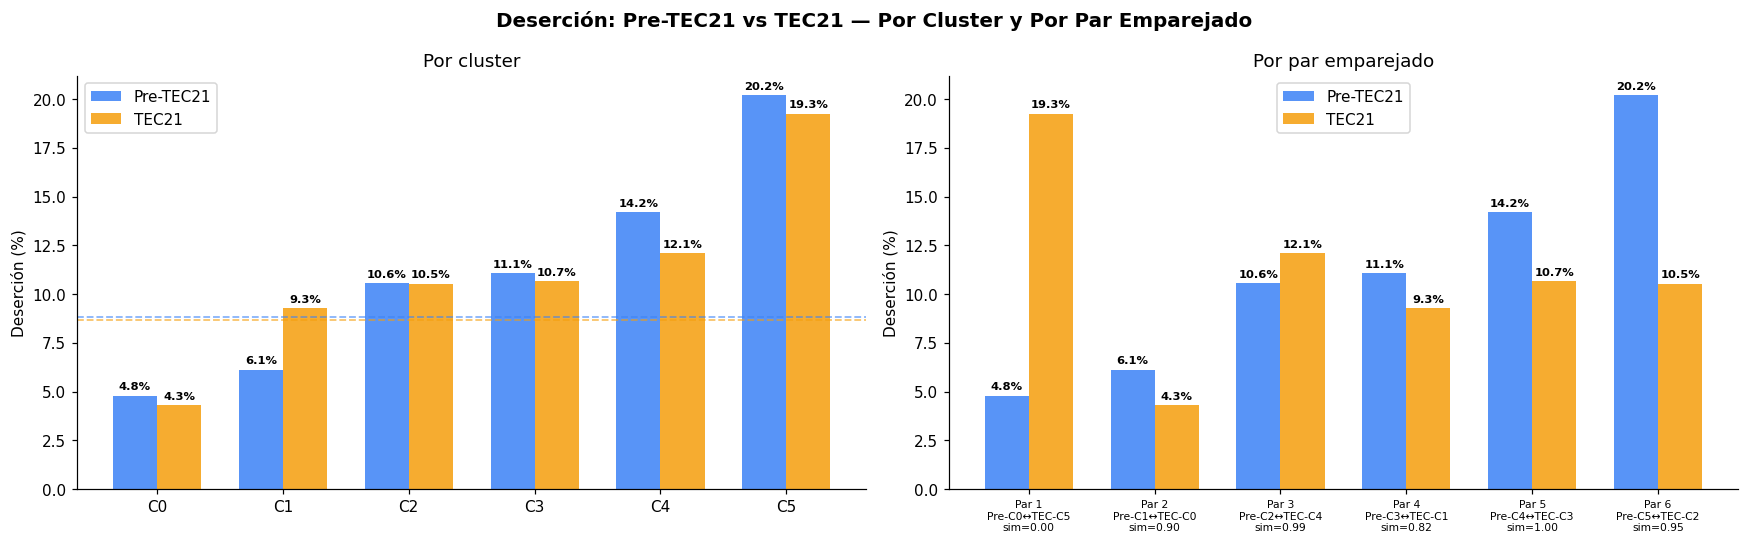

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Deserción: Pre-TEC21 vs TEC21 — Por Cluster y Por Par Emparejado',
             fontsize=13, fontweight='bold')

x, w = np.arange(K), 0.35
ax = axes[0]
b1 = ax.bar(x-w/2, prof_pre['Deserción (%)'], w, label='Pre-TEC21', color='#3b82f6', alpha=.85)
b2 = ax.bar(x+w/2, prof_tec['Deserción (%)'], w, label='TEC21',     color='#f59e0b', alpha=.85)
ax.axhline(y_pre.mean()*100, color='#3b82f6', ls='--', lw=1.2, alpha=.6)
ax.axhline(y_tec.mean()*100, color='#f59e0b', ls='--', lw=1.2, alpha=.6)
ax.set_xticks(x, labels=[f'C{k}' for k in range(K)])
ax.set_ylabel('Deserción (%)'); ax.set_title('Por cluster'); ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.2,
               f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax2 = axes[1]
plabels = [f'Par {i+1}\nPre-C{r}↔TEC-C{c}\nsim={s:.2f}' for i,(r,c,s) in enumerate(match_pairs)]
dp_ = [y_pre[lbl_pre==r].mean()*100 for r,c,_ in match_pairs]
dt_ = [y_tec[lbl_tec==c].mean()*100 for r,c,_ in match_pairs]
x2  = np.arange(len(match_pairs))
b3  = ax2.bar(x2-w/2, dp_, w, label='Pre-TEC21', color='#3b82f6', alpha=.85)
b4  = ax2.bar(x2+w/2, dt_, w, label='TEC21',     color='#f59e0b', alpha=.85)
ax2.set_xticks(x2, labels=plabels, fontsize=7)
ax2.set_ylabel('Deserción (%)'); ax2.set_title('Por par emparejado'); ax2.legend()
for bars in [b3, b4]:
    for bar in bars:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.2,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.tight_layout(); plt.show()


## 16. Diagnóstico K-Means: convergencia y separación

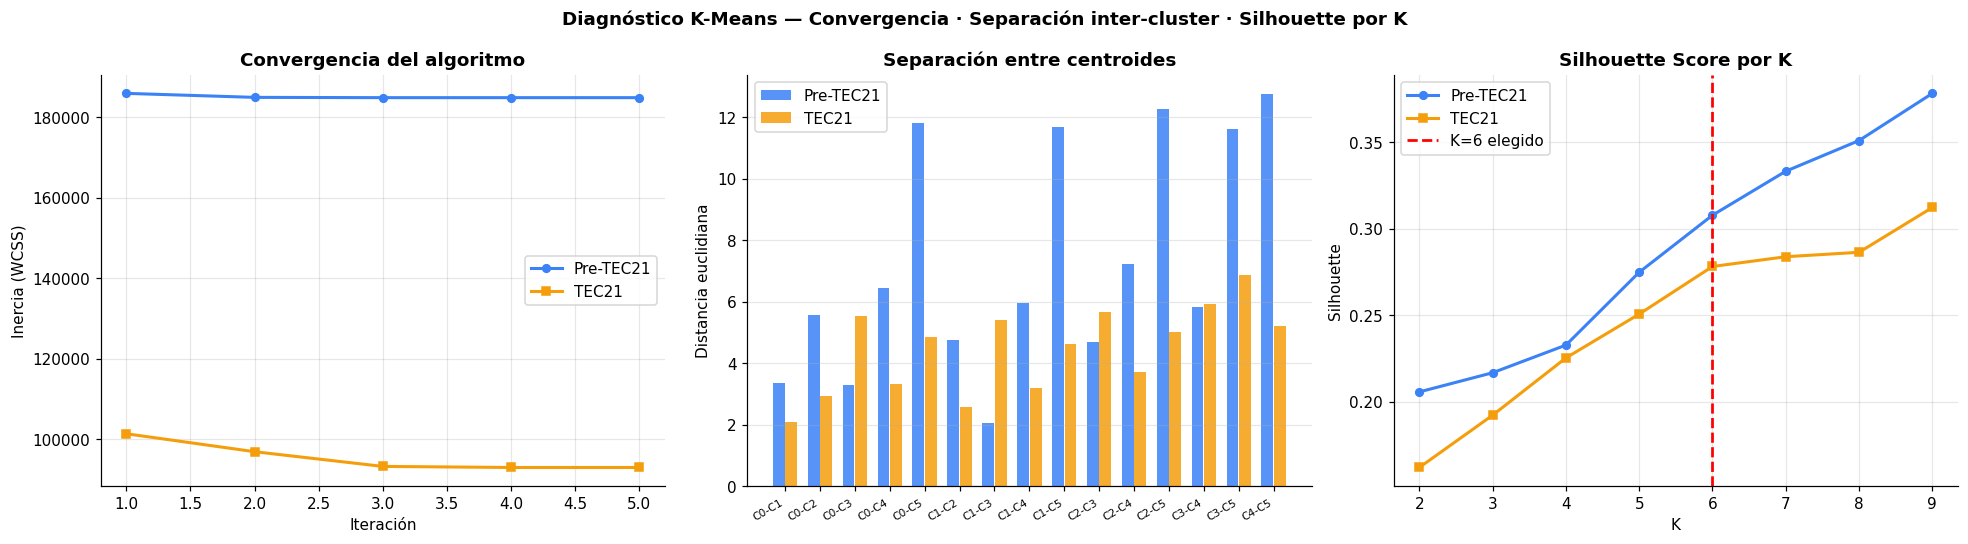

In [248]:
def convergence_curve(X, k=K, max_iter=40):
    km0 = KMeans(n_clusters=k, init='k-means++', n_init=1, max_iter=1, random_state=SEED).fit(X)
    centers = km0.cluster_centers_.copy()
    curve = [km0.inertia_]
    for it in range(2, max_iter+1):
        km = KMeans(n_clusters=k, init=centers, n_init=1, max_iter=it, tol=0, random_state=SEED).fit(X)
        curve.append(km.inertia_)
        centers = km.cluster_centers_.copy()
        if abs(curve[-2]-curve[-1]) < 1e-3:
            break
    return curve

conv_pre = convergence_curve(X_pre)
conv_tec = convergence_curve(X_tec)

# Distancias inter-centroide
def inter_dists(X, labels):
    cents = np.array([X[labels==k].mean(0) for k in range(K)])
    pairs_, dists_ = [], []
    for i in range(K):
        for j in range(i+1,K):
            pairs_.append(f'C{i}-C{j}')
            dists_.append(np.linalg.norm(cents[i]-cents[j]))
    return pairs_, dists_

pairs_p, dists_p = inter_dists(X_pre, lbl_pre)
pairs_t, dists_t = inter_dists(X_tec, lbl_tec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnóstico K-Means — Convergencia · Separación inter-cluster · Silhouette por K',
             fontsize=12, fontweight='bold')

# Convergencia
ax = axes[0]
ax.plot(range(1,len(conv_pre)+1), conv_pre, 'o-', color='#3b82f6', lw=2, ms=5, label='Pre-TEC21')
ax.plot(range(1,len(conv_tec)+1), conv_tec, 's-', color='#f59e0b', lw=2, ms=5, label='TEC21')
ax.set_xlabel('Iteración'); ax.set_ylabel('Inercia (WCSS)')
ax.set_title('Convergencia del algoritmo', fontweight='bold')
ax.legend(); ax.grid(alpha=.3)

# Distancias
ax2 = axes[1]
xd = np.arange(len(pairs_p))
ax2.bar(xd-.18, dists_p, .34, label='Pre-TEC21', color='#3b82f6', alpha=.85)
ax2.bar(xd+.18, dists_t, .34, label='TEC21',     color='#f59e0b', alpha=.85)
ax2.set_xticks(xd, labels=pairs_p, rotation=30, ha='right', fontsize=7)
ax2.set_ylabel('Distancia euclidiana'); ax2.set_title('Separación entre centroides', fontweight='bold')
ax2.legend(); ax2.grid(axis='y', alpha=.3)

# Silhouette por K
ax3 = axes[2]
ax3.plot(list(K_RANGE), s_pre, 'o-', color='#3b82f6', lw=2, ms=5, label='Pre-TEC21')
ax3.plot(list(K_RANGE), s_tec, 's-', color='#f59e0b', lw=2, ms=5, label='TEC21')
ax3.axvline(K, color='red', ls='--', lw=1.8, label=f'K={K} elegido')
ax3.set_xlabel('K'); ax3.set_ylabel('Silhouette')
ax3.set_title('Silhouette Score por K', fontweight='bold')
ax3.legend(); ax3.grid(alpha=.3)

plt.tight_layout(); plt.show()


## 17. Exportar dataset con cluster asignado

Genera dos CSVs — uno por grupo — con **todas las columnas originales** más:
- `cluster_id` : número de cluster asignado (0–5, ordenado por deserción ascendente)
- `cluster_label` : nombre descriptivo del cluster


In [249]:
CLUSTER_NAMES_PRE = {
    0: 'C0_prepa_sin_beca',
    1: 'C1_alto_pna_beca',
    2: 'C2_primera_gen_extracurr',
    3: 'C3_pna_bajo_sin_beca',
    4: 'C4_extranjeros',
    5: 'C5_sin_extracurriculares',
}
CLUSTER_NAMES_TEC = {
    0: 'C0_alto_pna_beca',
    1: 'C1_pna_bajo_sin_beca',
    2: 'C2_sin_extracurriculares',
    3: 'C3_extranjeros',
    4: 'C4_primera_gen',
    5: 'C5_perfil_vulnerable',
}

pre_out = pre_df.copy()
pre_out['cluster_id']    = lbl_pre
pre_out['cluster_label'] = [CLUSTER_NAMES_PRE[k] for k in lbl_pre]
pre_out.to_csv(OUT+'v5_dataset_pre_tec21_clusters.csv', index=False)

tec_out = tec_df.copy()
tec_out['cluster_id']    = lbl_tec
tec_out['cluster_label'] = [CLUSTER_NAMES_TEC[k] for k in lbl_tec]
tec_out.to_csv(OUT+'v5_dataset_tec21_clusters.csv', index=False)

# Resumen de distribución
print("=== Pre-TEC21 — distribución por cluster ===")
for k in range(K):
    m = lbl_pre==k
    print(f"  {CLUSTER_NAMES_PRE[k]:35s}  n={m.sum():>6,}  dropout={y_pre[m].mean()*100:.1f}%")
print()
print("=== TEC21 — distribución por cluster ===")
for k in range(K):
    m = lbl_tec==k
    print(f"  {CLUSTER_NAMES_TEC[k]:35s}  n={m.sum():>6,}  dropout={y_tec[m].mean()*100:.1f}%")
print()
print("✓ v5_dataset_pre_tec21_clusters.csv")
print("✓ v5_dataset_tec21_clusters.csv")
print(f"\nColumnas en el CSV: {list(pre_out.columns[-5:])}")


=== Pre-TEC21 — distribución por cluster ===
  C0_prepa_sin_beca                    n= 5,695  dropout=4.8%
  C1_alto_pna_beca                     n=18,221  dropout=6.1%
  C2_primera_gen_extracurr             n= 2,521  dropout=10.6%
  C3_pna_bajo_sin_beca                 n=24,505  dropout=11.1%
  C4_extranjeros                       n= 1,667  dropout=14.2%
  C5_sin_extracurriculares             n=   401  dropout=20.2%

=== TEC21 — distribución por cluster ===
  C0_alto_pna_beca                     n= 7,510  dropout=4.3%
  C1_pna_bajo_sin_beca                 n= 8,337  dropout=9.3%
  C2_sin_extracurriculares             n= 3,997  dropout=10.5%
  C3_extranjeros                       n=   938  dropout=10.7%
  C4_primera_gen                       n= 2,894  dropout=12.1%
  C5_perfil_vulnerable                 n=   831  dropout=19.3%

✓ v5_dataset_pre_tec21_clusters.csv
✓ v5_dataset_tec21_clusters.csv

Columnas en el CSV: ['school_EN', 'is_foreign', 'dropout', 'cluster_id', 'cluster_label']


---
## 18. Exportar dataset.csv original con cluster tags

Carga el `dataset.csv` completo (50 columnas originales), aplica los mismos
cluster labels usando el mismo orden de filas que el k_means dataset,
y exporta dos CSVs enriquecidos (`v6_*_full.csv`) con **todas** las columnas
originales más `cluster_id` y `cluster_label`.

In [ ]:
# ── Cargar dataset.csv original ───────────────────────────────────────────────
orig = pd.read_csv('../data/dataset.csv')

# Solo Undergraduate (77,517 filas — exactamente las mismas que dataset_k_means.csv)
orig_ug = orig[orig['level'] == 'Undergraduate'].reset_index(drop=True)
print(f"dataset.csv (Undergraduate): {orig_ug.shape}")

# Verificar alineación con los datos de clustering (PNA debe coincidir 1:1)
pna_ok = (orig_ug['PNA'].round(4).values == df_raw['PNA'].round(4).values).mean()
print(f"Verificación alineación (PNA match): {pna_ok:.4f} {'✓' if pna_ok==1.0 else '✗ ERROR'}")

# ── Crear is_foreign y dropout como en el análisis ────────────────────────────
orig_ug['is_foreign'] = (orig_ug['foreign'] == 'Yes: Foreigner').astype(int)
orig_ug['dropout']    = 1 - orig_ug['retention']

# ── Split Pre-TEC21 / TEC21 (mismo orden que pre_df y tec_df) ─────────────────
orig_pre = orig_ug[orig_ug['educational.model'] == 0].reset_index(drop=True)
orig_tec = orig_ug[orig_ug['educational.model'] == 1].reset_index(drop=True)

print(f"Pre-TEC21 original: {len(orig_pre):,} filas | TEC21: {len(orig_tec):,} filas")
print(f"Pre clusters disponibles: {len(lbl_pre):,} | TEC: {len(lbl_tec):,}")

# ── Asignar clusters por posición (filas en mismo orden) ──────────────────────
orig_pre['cluster_id']    = lbl_pre
orig_pre['cluster_label'] = [CLUSTER_NAMES_PRE[k] for k in lbl_pre]

orig_tec['cluster_id']    = lbl_tec
orig_tec['cluster_label'] = [CLUSTER_NAMES_TEC[k] for k in lbl_tec]

# ── Exportar ──────────────────────────────────────────────────────────────────
orig_pre.to_csv(OUT + 'v6_dataset_pre_tec21_full.csv', index=False)
orig_tec.to_csv(OUT + 'v6_dataset_tec21_full.csv', index=False)

print()
print(f"✓ v6_dataset_pre_tec21_full.csv  →  {orig_pre.shape[0]:,} filas × {orig_pre.shape[1]} cols")
print(f"✓ v6_dataset_tec21_full.csv      →  {orig_tec.shape[0]:,} filas × {orig_tec.shape[1]} cols")
print()
print("Columnas nuevas:", [c for c in orig_pre.columns if c not in orig.columns])
print()

# ── Verificación rápida de distribución ───────────────────────────────────────
print("Distribución clusters Pre-TEC21:")
print(orig_pre.groupby(['cluster_id','cluster_label'])['dropout']
             .agg(['count','mean']).rename(columns={'count':'n','mean':'dropout%'})
             .assign(**{'dropout%': lambda x: x['dropout%'].map('{:.1%}'.format)})
             .to_string())
print()
print("Distribución clusters TEC21:")
print(orig_tec.groupby(['cluster_id','cluster_label'])['dropout']
             .agg(['count','mean']).rename(columns={'count':'n','mean':'dropout%'})
             .assign(**{'dropout%': lambda x: x['dropout%'].map('{:.1%}'.format)})
             .to_string())